In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic_toy.csv')

In [5]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [9]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [10]:
x_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [11]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_age = x_train['Fare'].median()

In [12]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_age)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_age)

In [13]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
867,31.0,50.4958,0,31.0,31.0,50.4958,50.495800
805,31.0,7.7750,0,31.0,31.0,7.7750,7.775000
380,42.0,227.5250,0,42.0,42.0,227.5250,227.525000
59,11.0,46.9000,7,11.0,11.0,46.9000,46.900000
133,29.0,NaN,1,29.0,29.0,14.4583,29.785904


In [14]:
print('Original Age variable variance',x_train['Age'].var())
print('Age Variance after median imputation',x_train['Age_median'].var())
print('Age Variance after mean imputation',x_train['Age_mean'].var())

print('Original Fare variable variance',x_train['Fare'].var())
print('Fare Variance after median imputation',x_train['Fare_median'].var())
print('Fare Variance after mean imputation',x_train['Fare_mean'].var())

Original Age variable variance 204.3495133904614
Age Variance after median imputation 200.55085535155024
Age Variance after mean imputation 161.81262452718673
Original Fare variable variance 2448.197913706318
Fare Variance after median imputation 2340.0910219753637
Fare Variance after mean imputation 2324.623996772905


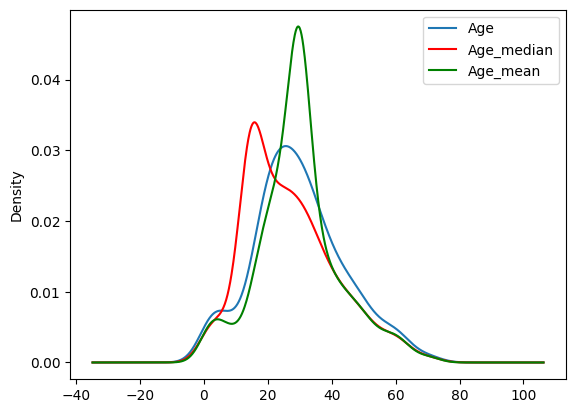

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

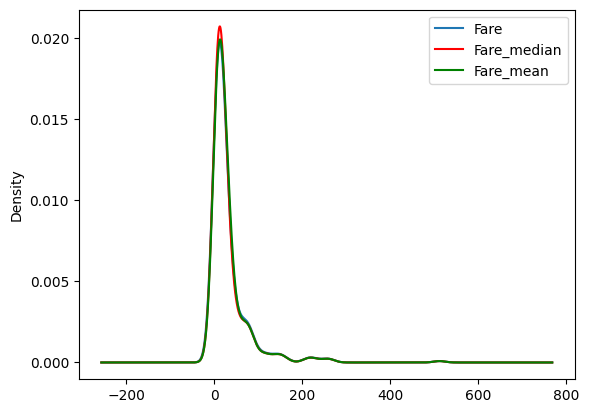

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [17]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.383530
Fare,70.719262,2448.197914,17.258917,90.432552,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-4.649792,-5.146106,16.476305,16.399278
Age_median,204.349513,90.432552,-4.649792,200.550855,161.812625,83.842733,85.540108
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.565299
Fare_median,64.858859,2448.197914,16.476305,83.842733,51.358000,2340.091022,2326.710504
Fare_mean,66.383530,2448.197914,16.399278,85.540108,52.565299,2326.710504,2324.623997


In [18]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.089754
Fare,0.092644,1.000000,0.208268,0.128809,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.198528,-0.244610,0.205942,0.205660
Age_median,1.000000,0.128809,-0.198528,1.000000,0.898243,0.122387,0.125280
Age_mean,1.000000,0.088069,-0.244610,0.898243,1.000000,0.083461,0.085707
Fare_median,0.087356,1.000000,0.205942,0.122387,0.083461,1.000000,0.997584
Fare_mean,0.089754,1.000000,0.205660,0.125280,0.085707,0.997584,1.000000


<Axes: >

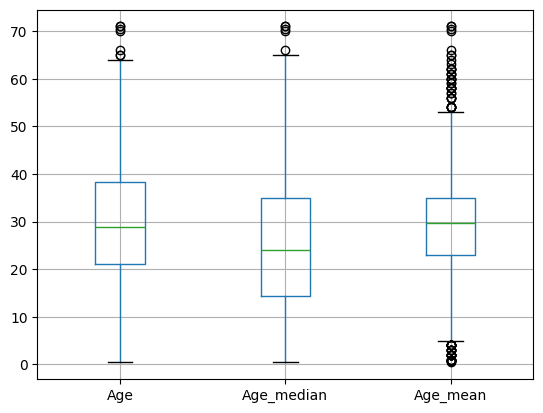

In [19]:
x_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

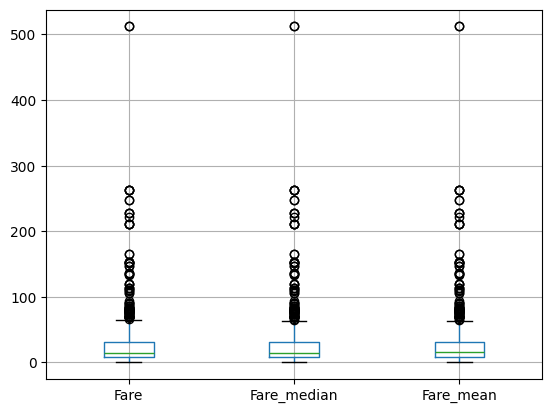

In [20]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

#### Using Sklearn

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [22]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [24]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [25]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [26]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [27]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [ ]:
x_train 